
Load Python libraries

In [2]:
import pandas as pd

import sys
!{sys.executable} -m pip install scikit-learn pandas matplotlib pennylane amazon-braket-pennylane-plugin

Loads cleaned data in QML notebook

In [3]:
df = pd.read_csv("../data/cleaned_wildfire_data.csv")
df.head()

,avg_tmax_c,avg_tmin_c,tot_prcp_mm,month,temp_range,hot_dry,zip3_890,zip3_894,zip3_895,zip3_900,...,zip3_959,zip3_960,zip3_961,zip3_975,zip3_976,risk,Year,zip,risk_score,predicted_risk
0,NaN,NaN,NaN,7.0,NaN,NaN,False,False,False,False,...,False,False,False,False,False,0,2019,95470.0,NaN,NaN
1,NaN,NaN,NaN,12.0,NaN,NaN,False,False,False,False,...,False,False,False,False,False,0,2018,93060.0,NaN,NaN
2,NaN,NaN,NaN,12.0,NaN,NaN,False,False,False,False,...,False,False,False,False,False,0,2018,93066.0,NaN,NaN
3,21.748387,11.432258,35.5,1.0,10.316129,0.61091,False,False,False,True,...,False,False,False,False,False,0,2018,90001.0,NaN,NaN
4,21.748387,11.432258,35.5,1.0,10.316129,0.61091,False,False,False,True,...,False,False,False,False,False,0,2018,90002.0,NaN,NaN


Selects quantum features (only uses 4 due to hardware limitations)

In [4]:
id_cols = ['zip', 'Year']
q_features = ['avg_tmax_c', 'tot_prcp_mm', 'month', 'hot_dry']
target = 'risk'

train_df = df[df['Year'] < 2023].copy()
test_df = df[df['Year'] == 2023].copy()

Xq_train = train_df[q_features]
yq_train = train_df[target].values

Xq_test = test_df[q_features]
yq_test = test_df[target].values

Fills empty NaN values with median of each column (since some quantum algorithms can't handle NaNs)

In [5]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

Xq_train_imputed = imputer.fit_transform(Xq_train)
Xq_test_imputed = imputer.transform(Xq_test)

Preprocessing for angle encoding on bounded angle range [-pi, pi]

In [6]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))

Xq_train_angles = scaler.fit_transform(Xq_train_imputed)
Xq_test_angles = scaler.transform(Xq_test_imputed)

Xq_train_angles[:3], Xq_test_angles[:3]

(array([[ 0.82031762, -3.11075073,  0.28559933, -2.93652035],
        [ 0.82031762, -3.11075073,  3.14159265, -2.93652035],
        [ 0.82031762, -3.11075073,  3.14159265, -2.93652035]]),
 array([[ 0.82031762, -3.11075073, -1.99919533, -2.93652035],
        [ 0.82031762, -3.11075073, -1.42799666, -2.93652035],
        [ 0.82031762, -3.11075073, -1.42799666, -2.93652035]]))

Shows how imbalanced the data is and then modifies for a 3:1 ratio (more managable for QML)

In [7]:
from sklearn.utils import resample

train_pos_idx = np.where(yq_train == 1)[0]
train_neg_idx = np.where(yq_train == 0)[0]

n_pos_sample = 10
n_neg_sample = 30

Transforms dataset into managable subset for training by randomly selecting positive and negative examples and building feature and label arrays

In [8]:
sampled_pos_idx = resample(train_pos_idx, replace=False, n_samples=n_pos_sample, random_state=42)
sampled_neg_idx = resample(train_neg_idx, replace=False, n_samples=n_neg_sample, random_state=42)

train_idx_small = np.concatenate([sampled_pos_idx, sampled_neg_idx])
np.random.shuffle(train_idx_small)

Xq_train_small = Xq_train_angles[train_idx_small]
Xq_train_small = np.asarray(Xq_train_small, dtype=np.float64)
yq_train_small = yq_train[train_idx_small]
yq_train_small = np.asarray(yq_train_small, dtype=np.float64)

print("Small train set shape:", Xq_train_small.shape)
print("Positive rate:", yq_train_small.mean())

Small train set shape: (40, 4)
Positive rate: 0.25


Imports qml features

In [9]:
import pennylane as qml
from pennylane import numpy as pnp

TRAIN_BACKEND = 'local'
INFER_BACKEND = 'sv1'   # later change to 'qpu' for hardware
N_SHOTS_SV1 = 50
N_SHOTS_QPU = 100
QPU_ARN = None

Defines the circuit by turning it into an optimizable function with angle encoding and entanglement

In [10]:
n_qubits = 4
n_layers = 2

print("TRAIN_BACKEND =", TRAIN_BACKEND)
print("INFER_BACKEND =", INFER_BACKEND)

# training device: always local
if TRAIN_BACKEND == 'local':
    train_dev = qml.device('default.qubit', wires=n_qubits)
else:
    raise ValueError("TRAIN_BACKEND must be 'local' for training.")

# inference device: local, sv1, or qpu
if INFER_BACKEND == 'local':
    infer_dev = qml.device('default.qubit', wires=n_qubits)

elif INFER_BACKEND == 'sv1':
    infer_dev = qml.device(
        'braket.aws.qubit',
        device_arn='arn:aws:braket:::device/quantum-simulator/amazon/sv1',
        wires=n_qubits,
        shots=N_SHOTS_SV1
    )

elif INFER_BACKEND == 'qpu':
    infer_dev = qml.device(
        'braket.aws.qubit',
        device_arn=QPU_ARN,
        wires=n_qubits,
        shots=N_SHOTS_QPU
    )

else:
    raise ValueError("INFER_BACKEND must be 'local', 'sv1', or 'qpu'.")

@qml.qnode(train_dev, interface='autograd')
def train_qnode(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

@qml.qnode(infer_dev, interface='autograd')
def infer_qnode(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

TRAIN_BACKEND = local
INFER_BACKEND = sv1


/home/ec2-user/anaconda3/envs/Braket/lib/python3.12/site-packages/pennylane/devices/legacy_facade.py:194: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


In [11]:
def quantum_model_train(x, weights):
    raw = train_qnode(x, weights)
    prob = (raw + 1) / 2
    return prob

def quantum_model_infer(x, weights):
    raw = infer_qnode(x, weights)
    prob = (raw + 1) / 2
    return prob

Computes weighted loss so that missing a real wildfire is more costly

In [12]:
eps = 1e-8

pos_weight = (len(yq_train_small) - yq_train_small.sum()) / yq_train_small.sum()
pos_weight = float(pos_weight)

Instantiates loss function

In [13]:
def weighted_bce_loss(weights, X, y, pos_weight=1.0):
    losses = []
    for xi, yi in zip(X, y):
        p = quantum_model_train(xi, weights)
        p = pnp.clip(p, eps, 1 - eps)

        if yi == 1:
            loss = (-pos_weight * pnp.log(p + eps))
        else:
            loss = (-pnp.log(1 - p + eps))
        losses.append(loss)

    return pnp.mean(pnp.array(losses))

Initializes weights

In [14]:
np.random.seed(42)

weights = pnp.array(0.01 * np.random.randn(n_layers, n_qubits, 3), requires_grad=True)

Chooses optimizer and epochs (train time)

In [15]:
opt = qml.AdamOptimizer(stepsize=0.02)

epochs = 1
loss_history = []

Training loop

In [16]:
import time

start = time.time()

In [17]:
for epoch in range(epochs):
    weights = opt.step(lambda w: weighted_bce_loss(w, Xq_train_small, yq_train_small, pos_weight), weights)
    loss_val = weighted_bce_loss(weights, Xq_train_small, yq_train_small, pos_weight)
    loss_history.append(loss_val)
    if(epoch % 5 == 0):
        print(f"Epoch {epoch}, Loss: {loss_val:.4f}")

end = time.time()
print("Total training time:", end - start)

Epoch 0, Loss: 1.1990
Total training time: 3.1766536235809326


Plots loss

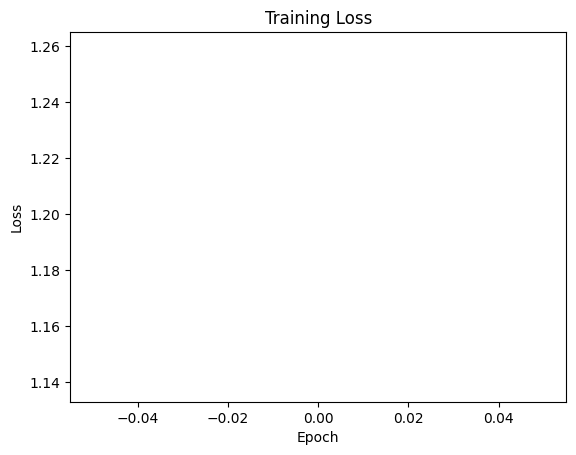

In [18]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

Prints some results after training (beyond loss)

In [19]:
def predict_probs_train(X, weights):
    return np.array([float(quantum_model_train(x, weights)) for x in X])

def predict_probs_infer(X, weights):
    return np.array([float(quantum_model_infer(x, weights)) for x in X])

# tiny comparison set
X_compare = Xq_test_angles[:5]
y_compare = yq_test[:5]

local_probs = predict_probs_train(X_compare, weights)
sv1_probs = predict_probs_infer(X_compare, weights)

print("True labels: ", y_compare)
print("Local probs: ", local_probs)
print("SV1 probs:   ", sv1_probs)

local_preds = (local_probs >= 0.5).astype(int)
sv1_preds = (sv1_probs >= 0.5).astype(int)

print("Local preds:", local_preds)
print("SV1 preds:  ", sv1_preds)

True labels:  [0 0 0 0 0]
Local probs:  [0.63292537 0.44642766 0.44642766 0.44642766 0.44642766]
SV1 probs:    [0.66 0.56 0.5  0.38 0.54]
Local preds: [1 0 0 0 0]
SV1 preds:   [1 1 1 0 1]


In [20]:
import time

start = time.time()
sv1_probs = predict_probs_infer(X_compare, weights)
end = time.time()

print("SV1 inference time for 5 samples:", end - start)
print("SV1 probs:", sv1_probs)

SV1 inference time for 5 samples: 13.57183575630188
SV1 probs: [0.62 0.3  0.46 0.52 0.42]


In [21]:
comparison_df = pd.DataFrame({
    "true_label": y_compare,
    "local_prob": local_probs,
    "sv1_prob": sv1_probs,
    "local_pred": local_preds,
    "sv1_pred": sv1_preds
})

comparison_df

,true_label,local_prob,sv1_prob,local_pred,sv1_pred
0,0,0.632925,0.62,1,1
1,0,0.446428,0.30,0,1
2,0,0.446428,0.46,0,1
3,0,0.446428,0.52,0,0
4,0,0.446428,0.42,0,1


Zip-level risk scores

In [22]:
test_probs_full_local = predict_probs_train(Xq_test_angles, weights)

results_df = test_df[id_cols + q_features + [target]].copy()
results_df['qml_risk_score'] = test_probs_full_local
results_df[['zip', 'Year', 'qml_risk_score']].head()

zip_scores = (
    results_df.groupby('zip', as_index=False)['qml_risk_score']
    .max()
    .sort_values('qml_risk_score', ascending=False)
)

zip_scores.head(10)

,zip,qml_risk_score
44,93308.0,0.833500
30,93226.0,0.833500
54,93453.0,0.833500
42,93287.0,0.833500
23,93066.0,0.833500
57,93465.0,0.833500
45,93401.0,0.783895
34,93249.0,0.783895
35,93251.0,0.783895
49,93428.0,0.783895
